In [ ]:
using LinearAlgebra
using Plots
pyplot()

# Constants
const k_g = 0.2     # Gravitational strength
const k_m = 20.0    # Magnetic strength
const gamma = 0.5   # Friction coefficient
const R = 1.0       # Radius of the magnetic ring
const h = 0.2       # Separation between planes
const tau = 0.001   # Integration time step

# Define the positions of the three magnetic poles
const r_poles = [
    [0.0, R],                                       # Top pole
    [R * cos(7 * pi / 6), R * sin(7 * pi / 6)],     # Bottom-left pole
    [R * cos(11 * pi / 6), R * sin(11 * pi / 6)]    # Bottom-right pole
]


# Function to calculate acceleration (a_x, a_y) given position and velocity
function acceleration(r, v)
    # Gravitational force component: -k_g * r
    a_g = -k_g .* r
    
    # Friction component: -gamma * v
    a_f = -gamma .* v
    
    # Magnetic force component
    a_m = [0.0, 0.0]
    for r_i in r_poles
        diff = r .- r_i
        dist_sq = diff[1]^2 + diff[2]^2
        denom = (dist_sq + h^2)^1.5
        a_m .-= k_m .* diff ./ denom
    end
    
    return a_g .+ a_f .+ a_m
end

# Right-hand side (RHS) of the first-order ODE system
# Takes state S = [x, y, v_x, v_y] and returns [v_x, v_y, a_x, a_y]
function rhs(S)
    r = S[1:2]
    v = S[3:4]
    a = acceleration(r, v)
    return [v[1], v[2], a[1], a[2]]
end

# RK4 Integrator
# Performs a single 4th-order Runge-Kutta step
function rk4_step(S, dt)
    k1 = rhs(S)
    k2 = rhs(S .+ 0.5 .* dt .* k1)
    k3 = rhs(S .+ 0.5 .* dt .* k2)
    k4 = rhs(S .+ dt .* k3)
    
    return S .+ (dt / 6.0) .* (k1 .+ 2.0 .* k2 .+ 2.0 .* k3 .+ k4)
end

# Simulation Loop
# Simulates the trajectory given an initial position (x0, y0) and total time
function simulate_pendulum(x0, y0, t_max)
    # Initial state: starting at (x0, y0) with zero initial velocity
    S = [x0, y0, 0.0, 0.0]
    
    # Calculate number of steps based on t_max and time step tau
    steps = round(Int, t_max / tau)
    
    # Pre-allocate arrays to store the trajectory for plotting
    x_traj = zeros(steps)
    y_traj = zeros(steps)
    
    # Run the integration loop
    for i in 1:steps
        x_traj[i] = S[1]
        y_traj[i] = S[2]
        
        # Update state using RK4
        S = rk4_step(S, tau)
    end
    
    return x_traj, y_traj
end


# Set total simulation time
t_max = 30.0 

# Choose an initial starting position
x0 = 1.0
y0 = 1.0

# Run the simulation
x_history, y_history = simulate_pendulum(x0, y0, t_max)

println("Simulation complete! Final position: (", x_history[end], ", ", y_history[end], ")")

# Plot the trajectory
plot(x_history, y_history, color=:blue, label="Traj. 1", xlabel="x", ylabel="y", title="Magnetic Pendulum Motion", legend=:topleft)

# Second simulation with random starting position
using Random
Random.seed!(43)  # For reproducibility
x0_rand = rand() * 2 - 1  # Random x between -1 and 1
y0_rand = rand() * 2 - 1  # Random y between -1 and 1
x_history2, y_history2 = simulate_pendulum(x0_rand, y0_rand, t_max)
plot!(x_history2, y_history2, color=:orange, label="Traj. 2")

# Third simulation with random starting position
Random.seed!(51)  # Different seed for variety
x0_rand3 = rand() * 2 - 1  # Random x between -1 and 1
y0_rand3 = rand() * 2 - 1  # Random y between -1 and 1
x_history3, y_history3 = simulate_pendulum(x0_rand3, y0_rand3, t_max)
plot!(x_history3, y_history3, color=:purple, label="Traj. 3")

# Mark starting points with small dots
scatter!([x0], [y0], color=:blue, markersize=4, label=false)
scatter!([x0_rand], [y0_rand], color=:orange, markersize=4, label=false)
scatter!([x0_rand3], [y0_rand3], color=:purple, markersize=4, label=false)

# Add the magnetic poles as red points
x_poles = [pole[1] for pole in r_poles]
y_poles = [pole[2] for pole in r_poles]
scatter!(x_poles, y_poles, color=:red, markersize=6, label="Poles")

#savefig("Aufgabe_2_1_a.png")

# %% [2.1 (b)]
# The pendulum stops at one of the points above the magnets (local potential minima).

function simulate_b(x0, y0, t_max_limit; v_tol=1e-4, a_tol=1e-4)
    S = [x0, y0, 0.0, 0.0] # Starting state: (x0, y0) with zero velocity
    steps = round(Int, t_max_limit / tau)
    
    # Dynamic Arrays to store the trajectory for plotting
    path_x = Float64[]
    path_y = Float64[]
    
    stop_time = t_max_limit
    
    for i in 1:steps
        push!(path_x, S[1])
        push!(path_y, S[2])
        
        r = S[1:2]
        v = S[3:4]
        a = acceleration(r, v)
        
        # End Circle: Check if velocity and acceleration are below the specified tolerances
        if norm(v) < v_tol && norm(a) < a_tol
            stop_time = i * tau
            break # Ends the simulation loop when the pendulum is considered "stopped"
        end
        
        S = rk4_step(S, tau)
    end
    
    return path_x, path_y, stop_time, S[1:2]
end

# Test the stopping for a time of 100 seconds
x0_test = 1.0
y0_test = 1.0
t_max_limit = 100.0

x_hist_b, y_hist_b, t_stop, final_pos = simulate_b(x0_test, y0_test, t_max_limit)

println("--- Ergebnisse Aufgabe b) ---")
println("Das Pendel stoppte nach: ", round(t_stop, digits=2), " Sekunden.")
println("Endposition (x, y): (", round(final_pos[1], digits=4), ", ", round(final_pos[2], digits=4), ")")

# Plot
plot(x_hist_b, y_hist_b, label="Trajektorie (Abbruch bei Stillstand)", linewidth=0.8, linealpha=0.6)
scatter!([p[1] for p in r_poles], [p[2] for p in r_poles], color=:red, markersize=8, markerstrokecolor=:black, markerstrokewidth=2, label="Pole")

#savefig("Aufgabe_2_1_b.png")

# %% [2.1 (c): Basins of Attraction / Gitter-Scan]

# Optimised function to determine which magnet the pendulum ends up at for a given initial position.
function get_final_magnet(x0, y0, t_max_limit; v_tol=1e-3, a_tol=1e-3, dt=0.01)
    S = [x0, y0, 0.0, 0.0]
    steps = round(Int, t_max_limit / dt)
    
    for _ in 1:steps
        r = S[1:2]
        v = S[3:4]
        a = acceleration(r, v) 
        
        # Stopping condition
        if norm(v) < v_tol && norm(a) < a_tol
            break
        end
        
        S = rk4_step(S, dt)
    end
    
    # Final position
    final_pos = S[1:2]
    
    # Determine which magnet is closest to the final position
    min_dist = Inf
    magnet_index = 0
    for (i, pole) in enumerate(r_poles)
        dist = norm(final_pos .- pole)
        if dist < min_dist
            min_dist = dist
            magnet_index = i
        end
    end
    
    return magnet_index
end

# Lattice parameters
N = 200
x_range = range(-2.0, 2.0, length=N)
y_range = range(-2.0, 2.0, length=N)


# Results matrix to store which magnet each point in the grid ends up at
Z = zeros(Int, N, N)

# Iterate over the grid and determine the final magnet for each initial position
@time for (i, y) in enumerate(y_range)
    for (j, x) in enumerate(x_range)
        Z[i, j] = get_final_magnet(x, y, 100.0) 
    end
end

# Plot as a heatmap
heatmap(x_range, y_range, Z, 
        c = cgrad([:red, :blue, :green]), # color coding
        xlabel="x", ylabel="y", 
        title="Basins of Attraction",
        colorbar=false,
        aspect_ratio=:equal)

# Poles as black points
scatter!([p[1] for p in r_poles], [p[2] for p in r_poles], 
         color=:black, markersize=4, label="")

savefig("Aufgabe_2_1_c.png")

Simulation complete! Final position: (-0.8620421367581363, -0.4975580803771855)
--- Ergebnisse Aufgabe b) ---
Das Pendel stoppte nach: 55.4 Sekunden.
Endposition (x, y): (-0.862, -0.4977)
332.061498 seconds (19.11 G allocations: 733.363 GiB, 18.05% gc time, 0.02% compilation time)


<sys>:0: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


"/Users/jp/Documents/vscode/Computational Physics/Sheet2/Aufgabe_2_1_c.png"

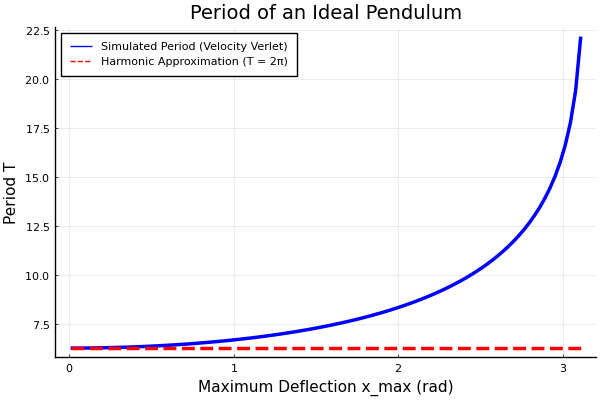

"/Users/jp/Documents/vscode/Computational Physics/Sheet2/Aufgabe_2_2.png"

In [ ]:
# %% [Exercise 2.2: Period of the Ideal Pendulum]
using Plots

# Acceleration of the ideal pendulum (assuming omega_0^2 = 1)
# Equation of motion: x'' = -sin(x)
get_accel(x) = -sin(x)

# Function to simulate one quarter-swing using Velocity Verlet
# and return the full period T.
function calculate_period(x_max; dt=0.001)
    x = x_max
    v = 0.0
    t = 0.0
    
    a = get_accel(x)
    
    while true
        # Velocity Verlet Step 1: Update position
        x_next = x + v * dt + 0.5 * a * dt^2
        
        # Velocity Verlet Step 2: Update acceleration
        a_next = get_accel(x_next)
        
        # Velocity Verlet Step 3: Update velocity
        v_next = v + 0.5 * (a + a_next) * dt
        t_next = t + dt
        
        # Check if the pendulum has crossed the vertical axis (x = 0)
        if x_next <= 0.0
            # Linear interpolation to find the exact time it crossed 0
            # This makes the result highly accurate without needing a tiny dt
            fraction = x / (x - x_next)
            t_quarter = t + fraction * dt
            
            # The full period is 4 times the time it takes to reach the center
            return 4.0 * t_quarter
        end
        
        # Prepare for next iteration
        x = x_next
        v = v_next
        a = a_next
        t = t_next
    end
end

# Define an array of starting deflections (from small angle to almost pi)
# (Avoid exactly 0 or pi to prevent numerical stagnation)
x_max_values = range(0.01, 0.99 * pi, length=100)

# Calculate the simulated period for each x_max
T_simulated = calculate_period.(x_max_values)

# Calculate the harmonic approximation (T = 2π for all x_max)
T_harmonic = fill(2 * pi, length(x_max_values))

# Plot the results
p2 = plot(x_max_values, T_simulated, 
    label="Simulated Period (Velocity Verlet)", 
    linewidth=2.5, 
    color=:blue,
    xlabel="Maximum Deflection x_max (rad)", 
    ylabel="Period T", 
    title="Period of an Ideal Pendulum",
    legend=:topleft
)

plot!(p2, x_max_values, T_harmonic, 
    label="Harmonic Approximation (T = 2π)", 
    linestyle=:dash, 
    linewidth=2.5, 
    color=:red
)

# Display plot
display(p2)

# Save plot
savefig(p2, "Aufgabe_2_2.png")